# Survey: Software Engineering in the Era of Generative AI
## Q09 × Q10 — Task Usage vs. Perceived Usefulness

This notebook visualises two survey questions side-by-side per task:
- **Q09** – *For which tasks do you use generative AI?* (% of AI users who selected each task)
- **Q10** – *How useful do you find generative AI for the following tasks?* (stacked rating distribution)

### 1 · Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

### 2 · Q09 Data
Each tuple: `(label, usage_%, ci_lower_bound, ci_upper_bound)`

In [6]:
q09_data = [
    ("Brainstorming",                     80.6, 63.7, 90.8),
    ("Code generation / auto-completion", 74.2, 56.8, 86.3),
    ("Debugging / Error Explanation",     71.0, 53.4, 83.9),
    ("Test / Test case generation",       48.4, 32.0, 65.2),
    ("Code Documentation",                45.2, 29.2, 62.2),
    ("Self-development and Learning",     45.2, 29.2, 62.2),
    ("Refactoring existing code",         41.9, 26.4, 59.2),
    ("Code Review",                       35.5, 21.1, 53.1),
    ("Security Analysis",                 19.4,  9.2, 36.3),
    ("Code Translation / Migration",      12.9,  5.1, 28.9),
#    ("Automating Workflows",               3.2,  0.6, 16.2),
#    ("Requirements Analysis",              3.2,  0.6, 16.2),
    ("CI/CD Automation",                   3.2,  0.6, 16.2),
#    ("General (non-SW) questions",         3.2,  0.6, 16.2),
]

q09_labels = [d[0] for d in q09_data]
q09_pct    = np.array([d[1] for d in q09_data])
q09_ci_lo  = np.array([d[1] - d[2] for d in q09_data])   # lower error arm
q09_ci_hi  = np.array([d[3] - d[1] for d in q09_data])   # upper error arm

### 3 · Q10 Data
Percentages for each rating level per task (N/A responses excluded).  
Order: `[Not Useful, Somewhat Useful, Very Useful, Essential]`

In [7]:
RATINGS = ["Not Useful", "Somewhat Useful", "Very Useful", "Essential"]

q10_map = {
    "Brainstorming":                     [ 3.2, 29.0, 51.6, 16.1],
    "Code generation / auto-completion": [ 0.0, 25.8, 48.4, 25.8],
    "Debugging / Error Explanation":     [ 3.7, 33.3, 48.1, 14.8],
    "Test / Test case generation":       [ 0.0, 21.7, 60.9, 17.4],
    "Code Documentation":                [ 7.7, 34.6, 42.3, 15.4],
    "Self-development and Learning":     [ 3.6, 35.7, 57.1,  3.6],
    "Refactoring existing code":         [10.3, 44.8, 31.0, 13.8],
    "Code Review":                       [17.4, 34.8, 39.1,  8.7],
    "Security Analysis":                 [26.3, 42.1, 31.6,  0.0],
    "Code Translation / Migration":      [ 5.3, 21.1, 63.2, 10.5],
    "CI/CD Automation":                  [23.5, 52.9, 23.5,  0.0],
}

### 4 · Colour Palette

In [8]:
Q09_COLOR    = "#3a7abf"   # blue for usage bar
Q09_CI_COLOR = "#1a3a5c"   # darker blue for error bars

RATING_COLORS = {
    "Not Useful":      "#e05252",   # red
    "Somewhat Useful": "#f0a04b",   # amber
    "Very Useful":     "#5ba85f",   # green
    "Essential":       "#2d6a4f",   # dark green
}

### 5 · Build Chart

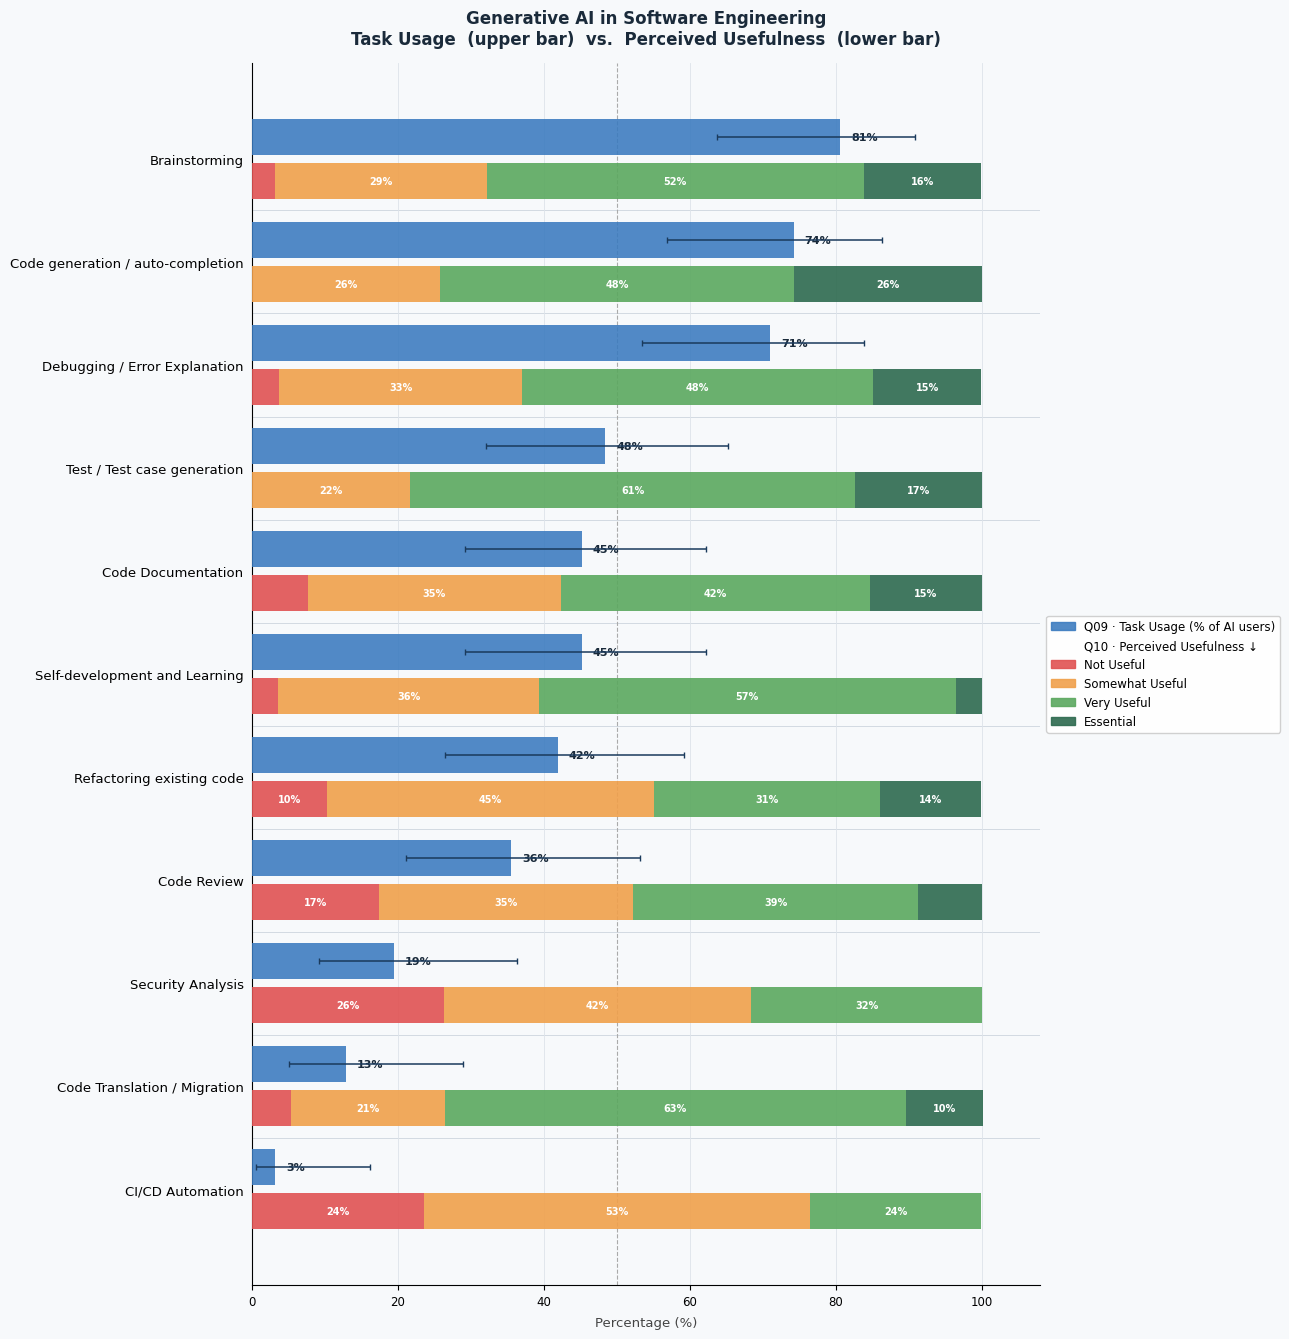

Saved → q09_q10_side_by_side.png


In [20]:
n = len(q09_labels)

GROUP_H = 1.0    # vertical space per task group
BAR_H   = 0.35   # height of each individual bar
GAP     = 0.08   # gap between the two bars within one group

fig_h = n * GROUP_H + 2.5
fig, ax = plt.subplots(figsize=(13, fig_h))
fig.patch.set_facecolor("#f7f9fb")
ax.set_facecolor("#f7f9fb")

# Y-positions (flipped so rank-1 appears at top)
task_centres = np.arange(n) * GROUP_H
y_q09 = (task_centres + BAR_H / 2 + GAP / 2)[::-1]   # upper bar per group
y_q10 = (task_centres - BAR_H / 2 - GAP / 2)[::-1]   # lower bar per group

for i, label in enumerate(q09_labels):

    # Q09 — usage bar
    ax.barh(y_q09[i], q09_pct[i], height=BAR_H,
            color=Q09_COLOR, alpha=0.88, zorder=3)
    ax.errorbar(q09_pct[i], y_q09[i],
                xerr=[[q09_ci_lo[i]], [q09_ci_hi[i]]],
                fmt="none", color=Q09_CI_COLOR,
                capsize=2.5, linewidth=1.1, zorder=4)
    ax.text(q09_pct[i] + 1.5, y_q09[i],
            f"{q09_pct[i]:.0f}%", va="center", ha="left",
            fontsize=8, color="#1a2a3a", fontweight="600")

    # Q10 — stacked usefulness bar
    if label in q10_map:
        left = 0.0
        for r_idx, rating in enumerate(RATINGS):
            val = q10_map[label][r_idx]
            if val > 0:
                ax.barh(y_q10[i], val, left=left, height=BAR_H,
                        color=RATING_COLORS[rating], alpha=0.90, zorder=3)
                if val >= 9:
                    ax.text(left + val / 2, y_q10[i],
                            f"{val:.0f}%", va="center", ha="center",
                            fontsize=7, color="white", fontweight="600")
            left += val
    else:
        ax.barh(y_q10[i], 100, height=BAR_H, color="#dedede", alpha=0.5, zorder=2)
        ax.text(50, y_q10[i], "no Q10 data", va="center", ha="center",
                fontsize=7, color="#999", style="italic")

    # Separator line between task groups
    if i < n - 1:
        sep_y = (y_q10[i] + y_q09[i + 1]) / 2
        ax.axhline(sep_y, color="#cdd5de", linewidth=0.6, zorder=1)

# Y-axis: task labels centred between the bar pairs
tick_y = (y_q09 + y_q10) / 2
ax.set_yticks(tick_y)
ax.set_yticklabels(q09_labels, fontsize=9.5)
ax.tick_params(axis="y", length=0, pad=6)

# X-axis
ax.set_xlim(0, 108)
ax.set_xlabel("Percentage (%)", fontsize=9.5, color="#444", labelpad=6)
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax.tick_params(axis="x", labelsize=8.5)
ax.axvline(50, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax.grid(axis="x", color="#dde3ea", linewidth=0.6, zorder=1)
ax.spines[["top", "right"]].set_visible(False)

# Legend
usage_patch    = mpatches.Patch(color=Q09_COLOR, alpha=0.88,
                                 label="Q09 · Task Usage (% of AI users)")
# NEW: dummy entry for Q10 header
q10_patch = mpatches.Patch(color='none',
                          label="Q10 · Perceived Usefulness ↓")

rating_patches = [mpatches.Patch(color=RATING_COLORS[r], alpha=0.90, label=r)
                  for r in RATINGS]
ax.legend(handles=[usage_patch, q10_patch, *rating_patches],
          loc="center left", bbox_to_anchor=(1.0, 0.5),
          fontsize=8.5,
          framealpha=0.9, edgecolor="#ccc")
# Title
ax.set_title(
    "Generative AI in Software Engineering\n"
    "Task Usage  (upper bar)  vs.  Perceived Usefulness  (lower bar)",
    fontsize=12, fontweight="bold", color="#1a2a3a", pad=14
)

plt.tight_layout()
plt.savefig("q09_q10_side_by_side.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → q09_q10_side_by_side.png")

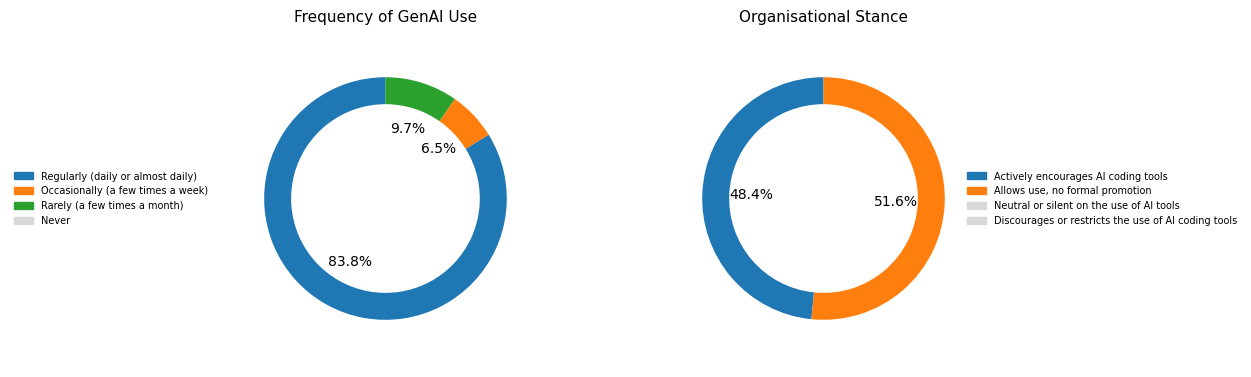

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def donut(ax, labels, sizes, title, legend_side="left"):
    # Pie uses only non-zero values
    labels_nonzero = [l for l, s in zip(labels, sizes) if s > 0]
    sizes_nonzero = [s for s in sizes if s > 0]

    wedges, _, _ = ax.pie(
        sizes_nonzero,
        autopct='%1.1f%%',
        startangle=90,
        radius=0.9,
        wedgeprops=dict(width=0.2),
        pctdistance=0.6
    )

    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)

    # Keep legend entries for all categories, including zero values
    colors_nonzero = [w.get_facecolor() for w in wedges]
    color_map = {}
    j = 0
    for label, size in zip(labels, sizes):
        if size > 0:
            color_map[label] = colors_nonzero[j]
            j += 1
        else:
            color_map[label] = "#d9d9d9"  # grey for zero-percentage options

    legend_handles = [
        mpatches.Patch(color=color_map[label], label=label)
        for label in labels
    ]

    # Your fixed legend positions
    if legend_side == "left":
        bbox = (-0.0, 0.5)
        loc = "center right"
    else:
        bbox = (0.9, 0.5)
        loc = "center left"

    ax.legend(
        handles=legend_handles,
        loc=loc,
        bbox_to_anchor=bbox,
        frameon=False,
        fontsize=7
    )

# Data
labels_q08 = [
    "Regularly (daily or almost daily)",
    "Occasionally (a few times a week)",
    "Rarely (a few times a month)",
    "Never"
]
sizes_q08 = [83.9, 6.5, 9.7, 0.0]

labels_q07 = [
    "Actively encourages AI coding tools",
    "Allows use, no formal promotion",
    "Neutral or silent on the use of AI tools", 
    "Discourages or restricts the use of AI coding tools"
]
sizes_q07 = [48.4, 51.6, 0.0, 0.0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

donut(axes[0], labels_q08, sizes_q08,
      "Frequency of GenAI Use", legend_side="left")
donut(axes[1], labels_q07, sizes_q07,
      "Organisational Stance", legend_side="right")

plt.subplots_adjust(wspace=0.3)
plt.show()